<a href="https://colab.research.google.com/github/Lekhana-Y/ML/blob/main/KNN_ml.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

KNN

In [90]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# 1. Load Data
df = pd.read_csv("diabetes_dataset.csv")

# Clean biologically impossible zero values
zero_cols = ["Glucose", "BMI"]
df[zero_cols] = df[zero_cols].replace(0, np.nan)

X = df[["Glucose", "BMI"]]
y = df["Outcome"]

# 2. Train-Test Split (use stratify for balanced class distributions)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# 3. Impute and Scale Features
imputer = SimpleImputer(strategy="median")
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(imputer.fit_transform(X_train))
X_test_scaled = scaler.transform(imputer.transform(X_test))

# 4. Model Training & Prediction
knn = KNeighborsClassifier(n_neighbors=11)
knn.fit(X_train_scaled, y_train)

y_pred = knn.predict(X_test_scaled)

# 5. Evaluation
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}\n")

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.7489

Confusion Matrix:
 [[131  19]
 [ 39  42]]

Classification Report:
               precision    recall  f1-score   support

           0       0.77      0.87      0.82       150
           1       0.69      0.52      0.59        81

    accuracy                           0.75       231
   macro avg       0.73      0.70      0.71       231
weighted avg       0.74      0.75      0.74       231



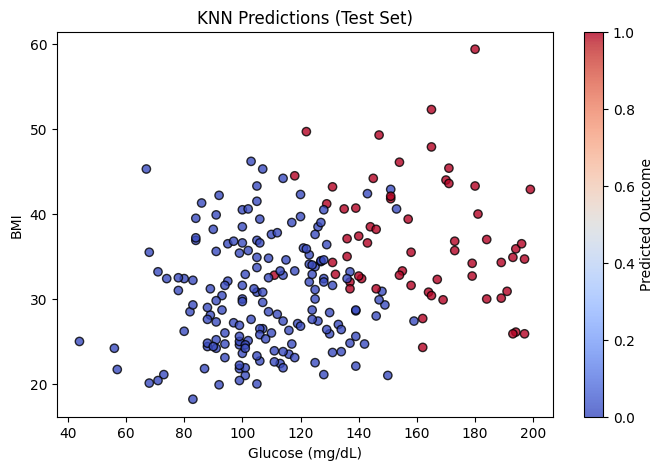

In [91]:
X_test_orig = imputer.transform(X_test)

plt.figure(figsize=(8, 5))
plt.scatter(
    X_test_orig[:, 0],
    X_test_orig[:, 1],
    c=y_pred,
    cmap="coolwarm",
    alpha=0.8,
    edgecolors="k"
)
plt.xlabel("Glucose (mg/dL)")
plt.ylabel("BMI")
plt.title("KNN Predictions (Test Set)")
plt.colorbar(label="Predicted Outcome")
plt.show()



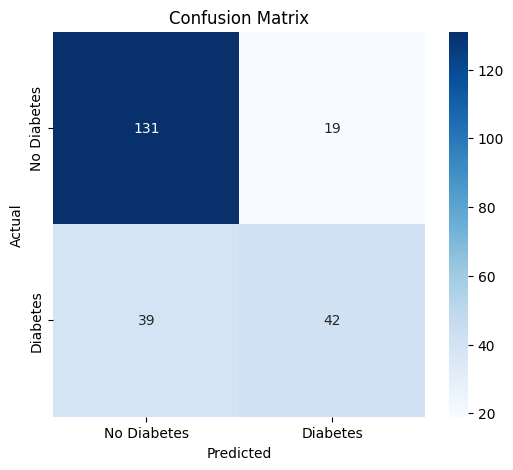

In [92]:
#  Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Diabetes", "Diabetes"],
    yticklabels=["No Diabetes", "Diabetes"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()